# Non Causal TF + Word2VEC 

In [6]:
import pandas as pd
import numpy as np
import pickle
import gensim.downloader as api
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

In [8]:
# 1. Load data
print("Loading datasets...")
X_train_df = pd.read_csv("X_train.csv")
X_val_df = pd.read_csv("X_val.csv")
y_train_raw = pd.read_csv("y_train.csv")["sentiment_consolidated"]
y_val_raw = pd.read_csv("y_val.csv")["sentiment_consolidated"]

print(f"Train samples: {len(X_train_df)}, Validation samples: {len(X_val_df)}")

# Merge for safe sampling (no leakage)
X_train_df["sentiment_consolidated"] = y_train_raw
X_val_df["sentiment_consolidated"] = y_val_raw

# Define sample sizes
TRAIN_SAMPLE_SIZE = 30000
VAL_SAMPLE_SIZE = 6000

# Stratified sampling to avoid data leakage
X_train_df, _ = train_test_split(
    X_train_df,
    train_size=TRAIN_SAMPLE_SIZE,
    stratify=X_train_df["sentiment_consolidated"],
    random_state=42
)

X_val_df, _ = train_test_split(
    X_val_df,
    train_size=VAL_SAMPLE_SIZE,
    stratify=X_val_df["sentiment_consolidated"],
    random_state=42
)

# Separate features and labels again
y_train_raw = X_train_df.pop("sentiment_consolidated")
y_val_raw   = X_val_df.pop("sentiment_consolidated")

print("Sampled Train size:", len(X_train_df))
print("Sampled Val size:", len(X_val_df))
print("Train label distribution:\n", y_train_raw.value_counts(normalize=True))
print("Val label distribution:\n", y_val_raw.value_counts(normalize=True))

Loading datasets...
Train samples: 535425, Validation samples: 88233
Sampled Train size: 30000
Sampled Val size: 6000
Train label distribution:
 sentiment_consolidated
negative    0.333333
positive    0.333333
neutral     0.333333
Name: proportion, dtype: float64
Val label distribution:
 sentiment_consolidated
positive    0.674333
negative    0.173500
neutral     0.152167
Name: proportion, dtype: float64


In [10]:

# 2. Load LabelEncoder
print("Loading label encoder...")
with open("label_encoder.pkl", "rb") as f:
    le = pickle.load(f)

Loading label encoder...


C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.6.1 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [12]:
y_train = le.transform(y_train_raw)
y_val = le.transform(y_val_raw)
num_classes = len(le.classes_)
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat = to_categorical(y_val, num_classes)

print("Classes:", list(le.classes_))
print("Label distribution in train:", pd.Series(y_train).value_counts().to_dict())


Classes: ['negative', 'neutral', 'positive']
Label distribution in train: {0: 10000, 2: 10000, 1: 10000}


In [14]:
# 3. Load Word2Vec
print("Loading Word2Vec model...")
word2vec = api.load("word2vec-google-news-300")
embedding_dim = 300
max_len = 50


Loading Word2Vec model...


In [15]:
# 4. Convert tweets to Word2Vec embeddings
def text_to_embedding(texts, max_len=50):
    embeddings = []
    for i, text in enumerate(texts):
        tokens = str(text).split()
        vecs = [word2vec[word] for word in tokens if word in word2vec]
        if not vecs:
            vecs = [np.zeros(embedding_dim)]
        vecs = pad_sequences([vecs], maxlen=max_len, dtype='float32', padding='post', truncating='post')[0]
        embeddings.append(vecs)
        if i % 5000 == 0:  # Print progress
            print(f"Processed {i} samples...")
    return np.array(embeddings)

print("Converting training text to embeddings...")
X_train_embed = text_to_embedding(X_train_df["clean_tweet"], max_len)
print("Converting validation text to embeddings...")
X_val_embed = text_to_embedding(X_val_df["clean_tweet"], max_len)

print(f"Embedding shape (train): {X_train_embed.shape}")
print(f"Embedding shape (val):   {X_val_embed.shape}")

Converting training text to embeddings...
Processed 0 samples...
Processed 5000 samples...
Processed 10000 samples...
Processed 15000 samples...
Processed 20000 samples...
Processed 25000 samples...
Converting validation text to embeddings...
Processed 0 samples...
Processed 5000 samples...
Embedding shape (train): (30000, 50, 300)
Embedding shape (val):   (6000, 50, 300)


In [18]:
# 5. Create tf.data.Dataset for efficient parallel training
train_ds = tf.data.Dataset.from_tensor_slices((X_train_embed, y_train_cat)).shuffle(2048).batch(32).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val_embed, y_val_cat)).batch(32).prefetch(tf.data.AUTOTUNE)


In [20]:
# 6. Define Transformer-based model
def build_transformer_model():
    inputs = Input(shape=(max_len, embedding_dim))
    x = LayerNormalization()(inputs)
    x = MultiHeadAttention(num_heads=2, key_dim=embedding_dim)(x, x)
    x = Dropout(0.2)(x)
    x = LayerNormalization()(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    return Model(inputs, outputs)

model = build_transformer_model()
model.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 50, 300)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 50, 300)   │        600 │ input_layer[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 50, 300)   │    722,100 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 50, 300)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 300)   │        600 │ dropout_1[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 300)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     38,528 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │        387 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 762,215 (2.91 MB)

 Trainable params: 762,215 (2.91 MB)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [26]:
# 7. Train model
print("Training model...")
from tensorflow.keras.callbacks import EarlyStopping

# Define early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop],
    verbose=1  # Progress bar
)


Training model...
Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 101s 108ms/step - accuracy: 0.8103 - loss: 0.4751 - val_accuracy: 0.8022 - val_loss: 0.5580
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 108s 115ms/step - accuracy: 0.8132 - loss: 0.4665 - val_accuracy: 0.7932 - val_loss: 0.5839
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 107s 114ms/step - accuracy: 0.8145 - loss: 0.4618 - val_accuracy: 0.8008 - val_loss: 0.5865
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 115s 123ms/step - accuracy: 0.8223 - loss: 0.4523 - val_accuracy: 0.8177 - val_loss: 0.5532
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 98s 104ms/step - accuracy: 0.8269 - loss: 0.4388 - val_accuracy: 0.7828 - val_loss: 0.6325
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 99s 105ms/step - accuracy: 0.8314 - loss: 0.4318 - val_accuracy: 0.8203 - val_loss: 0.5523
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 97s 103ms/step - accuracy: 0.8384 - loss: 0.4157 - val_accuracy: 0.8108 - val_loss: 0.5605
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 118s 126ms/step - acc

In [27]:
# Step 8: Save the trained model
model.save("transformer_sentiment_model.h5")
print("Model saved to 'transformer_sentiment_model.h5'")


Model saved to 'transformer_sentiment_model.h5'


## Classification Report

In [37]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import numpy as np

# Predict on validation set
y_val_pred_proba = model.predict(X_val_embed, batch_size=32)
y_val_pred = np.argmax(y_val_pred_proba, axis=1)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, target_names=le.classes_))

# ROC AUC (macro)
if num_classes > 2:
    y_val_bin = to_categorical(y_val, num_classes)
    auc_score = roc_auc_score(y_val_bin, y_val_pred_proba, average="macro", multi_class="ovr")
else:
    auc_score = roc_auc_score(y_val, y_val_pred_proba[:, 1])
print(f"\nROC AUC Score (macro): {auc_score:.4f}")


188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step

Classification Report:
              precision    recall  f1-score   support

    negative       0.70      0.72      0.71      1041
     neutral       0.56      0.64      0.59       913
    positive       0.92      0.89      0.91      4046

    accuracy                           0.82      6000
   macro avg       0.73      0.75      0.74      6000
weighted avg       0.83      0.82      0.82      6000


ROC AUC Score (macro): 0.9159


## Confusion Matrix

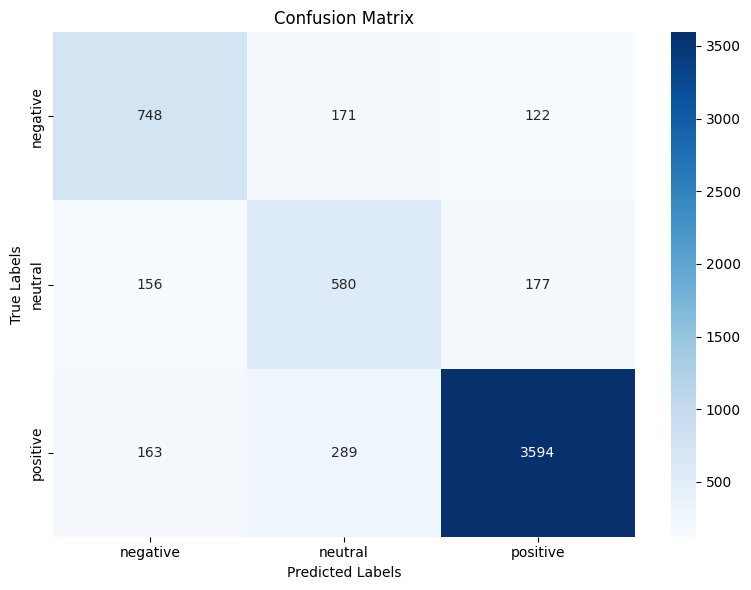

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_val, y_val_pred)

# Plot it
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


In [41]:
# Save predictions to CSV
val_predictions_df = pd.DataFrame({
    "original_text": X_val_df["clean_tweet"],
    "true_label": le.inverse_transform(y_val),
    "predicted_label": le.inverse_transform(y_val_pred)
})
val_predictions_df.to_csv("val_predictions.csv", index=False)
print("Saved predictions to 'val_predictions.csv'")


Saved predictions to 'val_predictions.csv'


##  Train vs Validation Accuracy

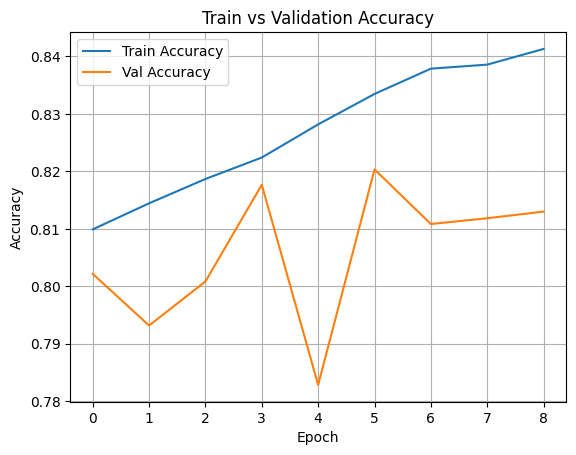

In [58]:
# Overfitting Check: Train vs Validation Accuracy
import matplotlib.pyplot as plt

# Plot train/val accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


In [56]:
#  Performance Across Classes
from sklearn.metrics import classification_report

print("Performance across classes:\n")
print(classification_report(y_val, y_val_pred, target_names=le.classes_))


Performance across classes:

              precision    recall  f1-score   support

    negative       0.70      0.72      0.71      1041
     neutral       0.56      0.64      0.59       913
    positive       0.92      0.89      0.91      4046

    accuracy                           0.82      6000
   macro avg       0.73      0.75      0.74      6000
weighted avg       0.83      0.82      0.82      6000



In [60]:
# AUC vs Accuracy
from sklearn.metrics import accuracy_score, roc_auc_score

val_accuracy = accuracy_score(y_val, y_val_pred)
if num_classes > 2:
    y_val_bin = to_categorical(y_val, num_classes)
    val_auc = roc_auc_score(y_val_bin, y_val_pred_proba, average="macro", multi_class="ovr")
else:
    val_auc = roc_auc_score(y_val, y_val_pred_proba[:, 1])

print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation AUC Score: {val_auc:.4f}")


Validation Accuracy: 0.8203
Validation AUC Score: 0.9159


In [62]:
# Performance Across Tweet Lengths
X_val_df["text_len"] = X_val_df["clean_tweet"].str.split().apply(len)
X_val_df["true_label"] = y_val
X_val_df["pred_label"] = y_val_pred

bins = [0, 5, 10, 15, 25, 50, 100]
X_val_df["length_bin"] = pd.cut(X_val_df["text_len"], bins)

print("Accuracy across tweet length bins:")
print(X_val_df.groupby("length_bin").apply(lambda df: (df["true_label"] == df["pred_label"]).mean()))


Accuracy across tweet length bins:
length_bin
(0, 5]       0.904360
(5, 10]      0.880286
(10, 15]     0.825781
(15, 25]     0.740816
(25, 50]     0.791328
(50, 100]    0.000000
dtype: float64


C:\Users\Dell\AppData\Local\Temp\ipykernel_1352\44100841.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(X_val_df.groupby("length_bin").apply(lambda df: (df["true_label"] == df["pred_label"]).mean()))
C:\Users\Dell\AppData\Local\Temp\ipykernel_1352\44100841.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(X_val_df.groupby("length_bin").apply(lambda df: (df["true_label"] == df["pred_label"]).mean()))


In [68]:
!pip install emoji

   ---------------------------------------- 0.0/590.6 kB ? eta -:--:--
   ---------------------------------------- 0.0/590.6 kB ? eta -:--:--
    --------------------------------------- 10.2/590.6 kB ? eta -:--:--
   ---- ---------------------------------- 61.4/590.6 kB 656.4 kB/s eta 0:00:01
   ------ -------------------------------- 92.2/590.6 kB 751.6 kB/s eta 0:00:01
   ---------------------- ----------------- 337.9/590.6 kB 1.8 MB/s eta 0:00:01
   ---------------------------------------- 590.6/590.6 kB 2.9 MB/s eta 0:00:00


In [69]:
# Performance With/Without Emojis
import emoji

def contains_emoji(text):
    return any(char in emoji.EMOJI_DATA for char in text)

X_val_df["has_emoji"] = X_val_df["clean_tweet"].apply(contains_emoji)

print("Accuracy with emojis:", (X_val_df[X_val_df["has_emoji"]]["true_label"] == X_val_df[X_val_df["has_emoji"]]["pred_label"]).mean())
print("Accuracy without emojis:", (X_val_df[~X_val_df["has_emoji"]]["true_label"] == X_val_df[~X_val_df["has_emoji"]]["pred_label"]).mean())


Accuracy with emojis: nan
Accuracy without emojis: 0.8203333333333334


In [72]:
# Performance With/Without Hashtags
X_val_df["has_hashtag"] = X_val_df["clean_tweet"].str.contains("#")

print("Accuracy with hashtags:", (X_val_df[X_val_df["has_hashtag"]]["true_label"] == X_val_df[X_val_df["has_hashtag"]]["pred_label"]).mean())
print("Accuracy without hashtags:", (X_val_df[~X_val_df["has_hashtag"]]["true_label"] == X_val_df[~X_val_df["has_hashtag"]]["pred_label"]).mean())


Accuracy with hashtags: nan
Accuracy without hashtags: 0.8203333333333334


In [74]:
#  Interpretability: Check if "parks" is Top Positive Feature
from collections import Counter

positive_indices = np.where(y_val_pred == le.transform(["positive"])[0])[0]
positive_words = " ".join(X_val_df.iloc[positive_indices]["clean_tweet"]).split()
top_positive_words = Counter(positive_words).most_common(20)

print("Top 20 words in predicted positive tweets:")
print(top_positive_words)



Top 20 words in predicted positive tweets:
[('freedom', 3862), ('convoy', 3630), ('ottawa', 526), ('trucker', 509), ('canadian', 495), ('via', 464), ('canada', 457), ('people', 319), ('protest', 309), ('amp', 283), ('trudeau', 246), ('like', 241), ('support', 229), ('police', 228), ('right', 208), ('live', 183), ('u', 168), ('mandate', 155), ('government', 153), ('the_NEG', 149)]


Final Training Accuracy:     0.8413
Final Validation Accuracy:   0.8130
Accuracy Gap:                0.0283
Final Training Loss:         0.4036
Final Validation Loss:       0.5722
Loss Gap:                    0.1686
🟢 Good Fit: Model generalizes well.


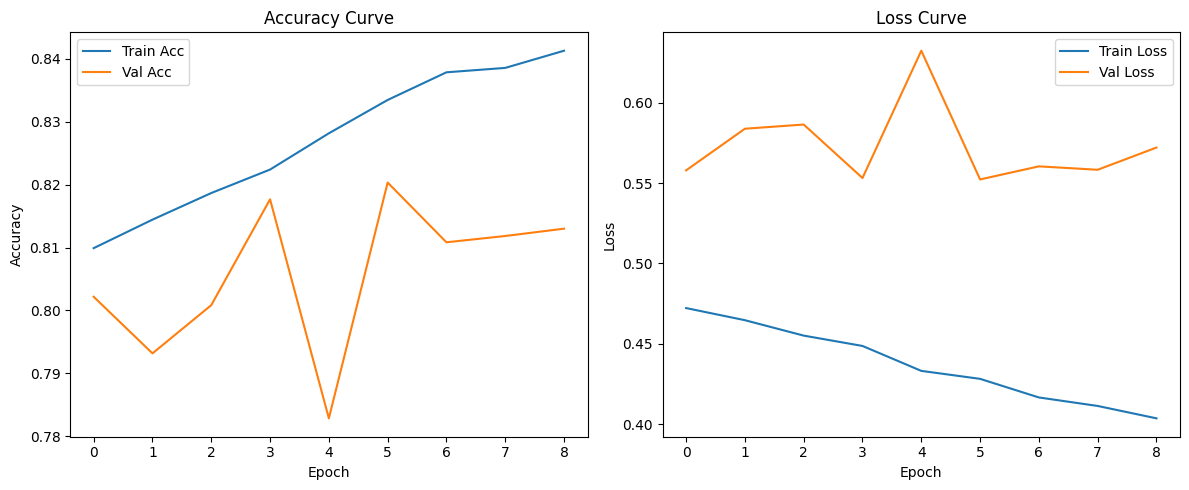

In [78]:
import numpy as np
import matplotlib.pyplot as plt

train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Final epoch values
final_train_acc = train_acc[-1]
final_val_acc = val_acc[-1]
final_train_loss = train_loss[-1]
final_val_loss = val_loss[-1]

# Accuracy gap
acc_gap = final_train_acc - final_val_acc
loss_gap = final_val_loss - final_train_loss

# Print summary
print(f"Final Training Accuracy:     {final_train_acc:.4f}")
print(f"Final Validation Accuracy:   {final_val_acc:.4f}")
print(f"Accuracy Gap:                {acc_gap:.4f}")
print(f"Final Training Loss:         {final_train_loss:.4f}")
print(f"Final Validation Loss:       {final_val_loss:.4f}")
print(f"Loss Gap:                    {loss_gap:.4f}")

# Diagnosis
if final_train_acc > 0.85 and acc_gap > 0.1:
    print("🔴 Likely Overfitting: Training acc high, validation lagging.")
elif final_train_acc < 0.7 and final_val_acc < 0.7:
    print("🟡 Likely Underfitting: Model fails to learn patterns.")
elif acc_gap < 0.05 and final_val_acc > 0.75:
    print("🟢 Good Fit: Model generalizes well.")
else:
    print("⚠️ Borderline: May need more data or tuning.")

# Optional: Plot loss and accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_acc, label='Train Acc')
plt.plot(val_acc, label='Val Acc')
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


## 1st Round Empricial Tunning

In [80]:
def build_tuned_transformer():
    inputs = Input(shape=(max_len, embedding_dim))
    
    # Normalize input
    x = LayerNormalization()(inputs)
    
    # Multi-head Attention with slightly higher heads
    attn = MultiHeadAttention(num_heads=4, key_dim=embedding_dim)(x, x)
    x = Dropout(0.25)(attn)  # Reduced dropout
    
    # Layer Norm again
    x = LayerNormalization()(x)
    
    # Global Average Pooling and Dense Layers
    x = GlobalAveragePooling1D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    
    outputs = Dense(num_classes, activation='softmax')(x)
    
    return Model(inputs, outputs)

model = build_tuned_transformer()
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])


In [84]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 305s 323ms/step - accuracy: 0.6419 - loss: 0.8069 - val_accuracy: 0.7978 - val_loss: 0.5480 - learning_rate: 1.0000e-04
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 186s 198ms/step - accuracy: 0.7178 - loss: 0.6700 - val_accuracy: 0.7578 - val_loss: 0.6345 - learning_rate: 1.0000e-04
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 189s 201ms/step - accuracy: 0.7397 - loss: 0.6334 - val_accuracy: 0.8032 - val_loss: 0.5295 - learning_rate: 1.0000e-04
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 193s 206ms/step - accuracy: 0.7506 - loss: 0.6094 - val_accuracy: 0.7887 - val_loss: 0.5649 - learning_rate: 1.0000e-04
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 188s 200ms/step - accuracy: 0.7610 - loss: 0.5884 - val_accuracy: 0.8180 - val_loss: 0.5020 - learning_rate: 1.0000e-04
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 191s 203ms/step - accuracy: 0.7620 - loss: 0.5754 - val_accuracy: 0.8157 - val_loss: 0.5171 - learning_rate: 1.0000e-04
Epoch 7/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 

In [86]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=1e-4, clipnorm=1.0)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])


In [95]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from collections import Counter
import emoji

# ---------- Make Predictions ----------
print("Generating predictions...")
y_val_pred_proba = model.predict(X_val_embed, batch_size=32)
y_val_pred = np.argmax(y_val_pred_proba, axis=1)

# ---------- Accuracy and AUC ----------
val_accuracy = accuracy_score(y_val, y_val_pred)

if num_classes > 2:
    y_val_bin = to_categorical(y_val, num_classes)
    val_auc = roc_auc_score(y_val_bin, y_val_pred_proba, average="macro", multi_class="ovr")
else:
    val_auc = roc_auc_score(y_val, y_val_pred_proba[:, 1])

print(f"\n✅ Validation Accuracy: {val_accuracy:.4f}")
print(f"✅ ROC AUC Score (macro): {val_auc:.4f}")

# ---------- Classification Report ----------
print("\n📊 Classification Report:")
print(classification_report(y_val, y_val_pred, target_names=le.classes_))

Generating predictions...
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step

✅ Validation Accuracy: 0.8180
✅ ROC AUC Score (macro): 0.9145

📊 Classification Report:
              precision    recall  f1-score   support

    negative       0.71      0.72      0.72      1041
     neutral       0.54      0.63      0.58       913
    positive       0.92      0.89      0.90      4046

    accuracy                           0.82      6000
   macro avg       0.73      0.74      0.73      6000
weighted avg       0.83      0.82      0.82      6000



## Confusion Matrix

C:\Users\Dell\AppData\Local\Temp\ipykernel_1352\3973376967.py:16: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from current font.
  plt.tight_layout()
C:\Users\Dell\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


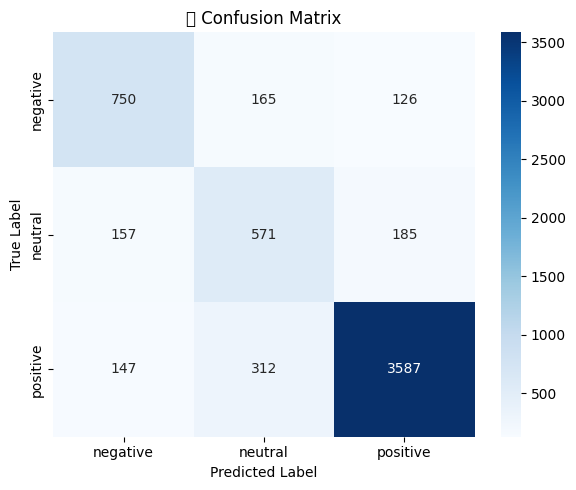

In [96]:
# ---------- Confusion Matrix ----------
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_val, y_val_pred)
class_names = le.classes_

# Plot it
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("🧩 Confusion Matrix")
plt.tight_layout()
plt.show()


In [99]:
# ---------- Tweet Length Analysis ----------
X_val_df["text_len"] = X_val_df["clean_tweet"].str.split().apply(len)
X_val_df["true_label"] = y_val
X_val_df["pred_label"] = y_val_pred

bins = [0, 5, 10, 15, 25, 50, 100]
X_val_df["length_bin"] = pd.cut(X_val_df["text_len"], bins)

print("\n📏 Accuracy by Tweet Length:")
print(X_val_df.groupby("length_bin").apply(lambda df: (df["true_label"] == df["pred_label"]).mean()))




📏 Accuracy by Tweet Length:
length_bin
(0, 5]       0.904360
(5, 10]      0.870756
(10, 15]     0.815625
(15, 25]     0.751531
(25, 50]     0.775068
(50, 100]    0.000000
dtype: float64


C:\Users\Dell\AppData\Local\Temp\ipykernel_1352\445400314.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(X_val_df.groupby("length_bin").apply(lambda df: (df["true_label"] == df["pred_label"]).mean()))
C:\Users\Dell\AppData\Local\Temp\ipykernel_1352\445400314.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(X_val_df.groupby("length_bin").apply(lambda df: (df["true_label"] == df["pred_label"]).mean()))


In [101]:
# ---------- Emoji Analysis ----------
def contains_emoji(text):
    return any(char in emoji.EMOJI_DATA for char in text)

X_val_df["has_emoji"] = X_val_df["clean_tweet"].apply(contains_emoji)

print("\n😀 Emoji Performance:")
print("With emojis accuracy:", (X_val_df[X_val_df["has_emoji"]]["true_label"] == X_val_df[X_val_df["has_emoji"]]["pred_label"]).mean())
print("Without emojis accuracy:", (X_val_df[~X_val_df["has_emoji"]]["true_label"] == X_val_df[~X_val_df["has_emoji"]]["pred_label"]).mean())


😀 Emoji Performance:
With emojis accuracy: nan
Without emojis accuracy: 0.818


In [103]:
# ---------- Hashtag Analysis ----------
X_val_df["has_hashtag"] = X_val_df["clean_tweet"].str.contains("#")

print("\n#️⃣ Hashtag Performance:")
print("With hashtags accuracy:", (X_val_df[X_val_df["has_hashtag"]]["true_label"] == X_val_df[X_val_df["has_hashtag"]]["pred_label"]).mean())
print("Without hashtags accuracy:", (X_val_df[~X_val_df["has_hashtag"]]["true_label"] == X_val_df[~X_val_df["has_hashtag"]]["pred_label"]).mean())


#️⃣ Hashtag Performance:
With hashtags accuracy: nan
Without hashtags accuracy: 0.818


In [105]:
# ---------- Top Words in Positive Predictions ----------
positive_indices = np.where(y_val_pred == le.transform(["positive"])[0])[0]
positive_words = " ".join(X_val_df.iloc[positive_indices]["clean_tweet"]).split()
top_positive_words = Counter(positive_words).most_common(20)

print("\n💬 Top 20 Words in Predicted Positive Tweets:")
for word, freq in top_positive_words:
    print(f"{word}: {freq}")


💬 Top 20 Words in Predicted Positive Tweets:
freedom: 3870
convoy: 3642
ottawa: 529
trucker: 522
canadian: 497
via: 462
canada: 452
people: 316
protest: 303
amp: 264
like: 260
trudeau: 244
support: 236
police: 225
right: 212
live: 182
u: 166
government: 165
mandate: 162
the_NEG: 159


## Accuracy & Loss Curves

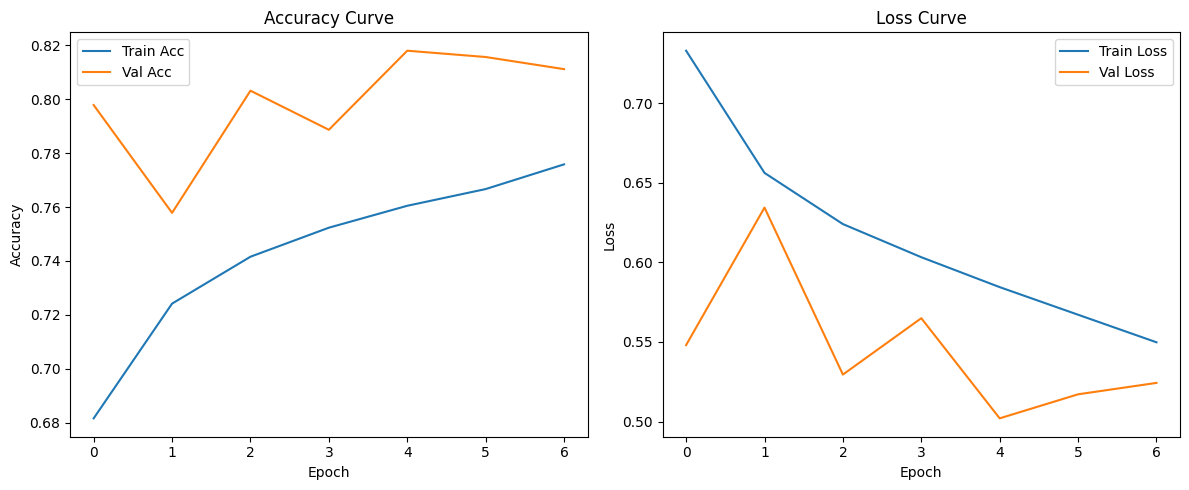

In [90]:
# Accuracy & Loss Curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


# 2nd Round Empirical Tunning

In [108]:
# Step 1: Define new Transformer model with modified hyperparameters
def build_second_tuned_transformer():
    inputs = Input(shape=(max_len, embedding_dim))
    
    # Layer Normalization
    x = LayerNormalization()(inputs)
    
    # Multi-head Attention with more heads
    attn = MultiHeadAttention(num_heads=6, key_dim=embedding_dim)(x, x)
    x = Dropout(0.2)(attn)  # slightly reduced dropout
    
    # Post-attention normalization
    x = LayerNormalization()(x)
    
    # Pooling and Dense layer
    x = GlobalAveragePooling1D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.35)(x)  # increased dropout
    
    # Output layer
    outputs = Dense(num_classes, activation='softmax')(x)
    
    return Model(inputs, outputs)


In [110]:
# Step 2: Compile model with a different optimizer setting
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=5e-5, clipnorm=2.0)

model = build_second_tuned_transformer()
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 50, 300)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 300)   │        600 │ input_layer_3[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 50, 300)   │  2,165,700 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 50, 300)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 300)   │        600 │ dropout_7[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 300)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │     77,056 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 256)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 3)         │        771 │ dropout_8[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,244,727 (8.56 MB)

 Trainable params: 2,244,727 (8.56 MB)

 Non-trainable params: 0 (0.00 B)

In [112]:
# Step 3: Train model with early stopping to prevent overfitting
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train_embed, y_train_cat,
    validation_data=(X_val_embed, y_val_cat),
    epochs=15,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 281s 588ms/step - accuracy: 0.6190 - loss: 0.8419 - val_accuracy: 0.7503 - val_loss: 0.6286
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 257s 547ms/step - accuracy: 0.7180 - loss: 0.6711 - val_accuracy: 0.8015 - val_loss: 0.5273
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 273s 582ms/step - accuracy: 0.7304 - loss: 0.6391 - val_accuracy: 0.7623 - val_loss: 0.6285
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 364s 672ms/step - accuracy: 0.7489 - loss: 0.6059 - val_accuracy: 0.7723 - val_loss: 0.5989
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 260s 553ms/step - accuracy: 0.7543 - loss: 0.5948 - val_accuracy: 0.7600 - val_loss: 0.6156


In [125]:
# Step 4: Evaluate model performance
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from tensorflow.keras.utils import to_categorical
import numpy as np

print("Generating predictions...")
y_val_pred_proba = model.predict(X_val_embed, batch_size=32)
y_val_pred = np.argmax(y_val_pred_proba, axis=1)

# Accuracy and AUC
val_accuracy = accuracy_score(y_val, y_val_pred)

if num_classes > 2:
    y_val_bin = to_categorical(y_val, num_classes)
    val_auc = roc_auc_score(y_val_bin, y_val_pred_proba, average="macro", multi_class="ovr")
else:
    val_auc = roc_auc_score(y_val, y_val_pred_proba[:, 1])

print(f"\n✅ Validation Accuracy (Round 2): {val_accuracy:.4f}")
print(f"✅ ROC AUC Score (macro) (Round 2): {val_auc:.4f}")

# Classification Report
print("\n📊 Classification Report (Round 2):")
print(classification_report(y_val, y_val_pred, target_names=le.classes_))

Generating predictions...
188/188 ━━━━━━━━━━━━━━━━━━━━ 17s 90ms/step

✅ Validation Accuracy (Round 2): 0.8015
✅ ROC AUC Score (macro) (Round 2): 0.9019

📊 Classification Report (Round 2):
              precision    recall  f1-score   support

    negative       0.66      0.71      0.68      1041
     neutral       0.53      0.55      0.54       913
    positive       0.91      0.88      0.90      4046

    accuracy                           0.80      6000
   macro avg       0.70      0.71      0.70      6000
weighted avg       0.81      0.80      0.80      6000




🧩 Confusion Matrix (Round 2):


C:\Users\Dell\AppData\Local\Temp\ipykernel_1352\3039740833.py:16: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from current font.
  plt.tight_layout()
C:\Users\Dell\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


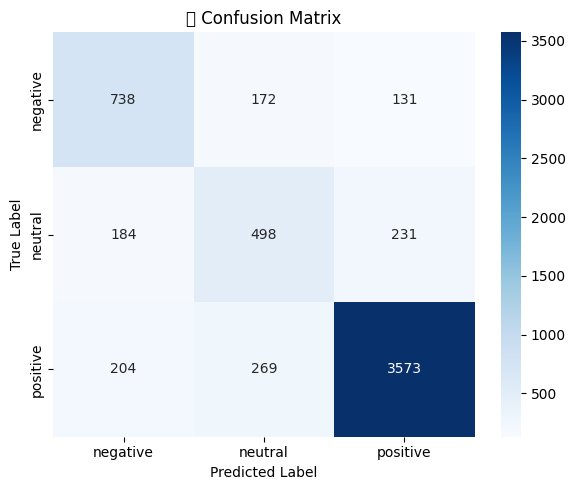

In [126]:
# ---------- Confusion Matrix ----------
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
print("\n🧩 Confusion Matrix (Round 2):")
# Compute confusion matrix
cm = confusion_matrix(y_val, y_val_pred)
class_names = le.classes_

# Plot it
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("🧩 Confusion Matrix")
plt.tight_layout()
plt.show()

In [127]:
# ---------- Emoji Analysis ----------
def contains_emoji(text):
    return any(char in emoji.EMOJI_DATA for char in text)

X_val_df["has_emoji"] = X_val_df["clean_tweet"].apply(contains_emoji)

print("\n😀 Emoji Performance:")
print("With emojis accuracy:", (X_val_df[X_val_df["has_emoji"]]["true_label"] == X_val_df[X_val_df["has_emoji"]]["pred_label"]).mean())
print("Without emojis accuracy:", (X_val_df[~X_val_df["has_emoji"]]["true_label"] == X_val_df[~X_val_df["has_emoji"]]["pred_label"]).mean())


😀 Emoji Performance:
With emojis accuracy: nan
Without emojis accuracy: 0.818


In [128]:
# ---------- Tweet Length Analysis ----------
X_val_df["text_len"] = X_val_df["clean_tweet"].str.split().apply(len)
X_val_df["true_label"] = y_val
X_val_df["pred_label"] = y_val_pred

bins = [0, 5, 10, 15, 25, 50, 100]
X_val_df["length_bin"] = pd.cut(X_val_df["text_len"], bins)

print("\n📏 Accuracy by Tweet Length:")
print(X_val_df.groupby("length_bin").apply(lambda df: (df["true_label"] == df["pred_label"]).mean()))




📏 Accuracy by Tweet Length:
length_bin
(0, 5]       0.883263
(5, 10]      0.851697
(10, 15]     0.792188
(15, 25]     0.738776
(25, 50]     0.780488
(50, 100]    1.000000
dtype: float64


C:\Users\Dell\AppData\Local\Temp\ipykernel_1352\445400314.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(X_val_df.groupby("length_bin").apply(lambda df: (df["true_label"] == df["pred_label"]).mean()))
C:\Users\Dell\AppData\Local\Temp\ipykernel_1352\445400314.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(X_val_df.groupby("length_bin").apply(lambda df: (df["true_label"] == df["pred_label"]).mean()))


In [129]:
# ---------- Hashtag Analysis ----------
X_val_df["has_hashtag"] = X_val_df["clean_tweet"].str.contains("#")

print("\n#️⃣ Hashtag Performance:")
print("With hashtags accuracy:", (X_val_df[X_val_df["has_hashtag"]]["true_label"] == X_val_df[X_val_df["has_hashtag"]]["pred_label"]).mean())
print("Without hashtags accuracy:", (X_val_df[~X_val_df["has_hashtag"]]["true_label"] == X_val_df[~X_val_df["has_hashtag"]]["pred_label"]).mean())


#️⃣ Hashtag Performance:
With hashtags accuracy: nan
Without hashtags accuracy: 0.8015


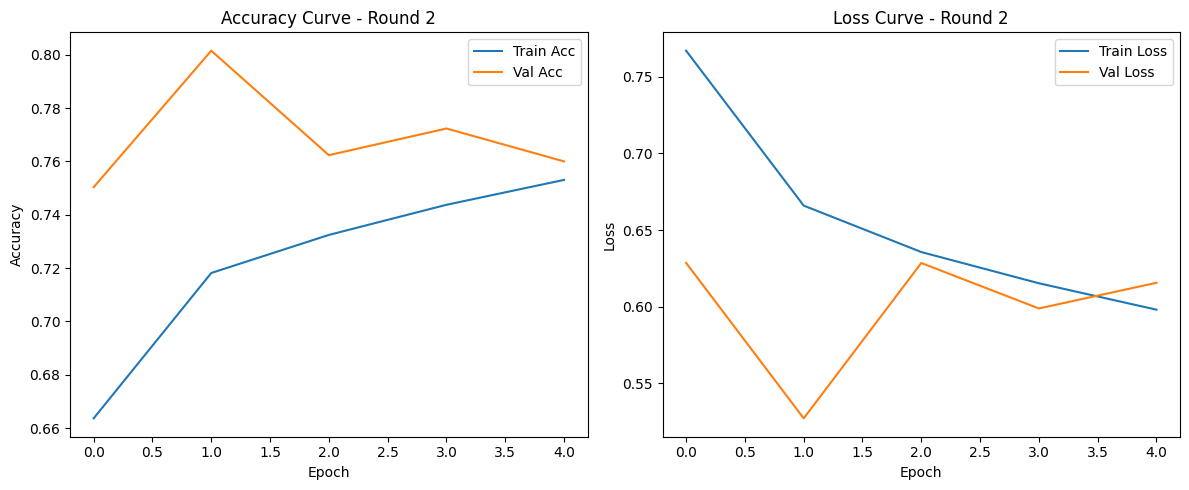

In [135]:
# Step 5: Plot training curves
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy Curve - Round 2")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Curve - Round 2")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


## Cross Validation

In [138]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
from tensorflow.keras.utils import to_categorical
import numpy as np


In [140]:
def build_final_transformer():
    inputs = Input(shape=(max_len, embedding_dim))
    x = LayerNormalization()(inputs)
    x = MultiHeadAttention(num_heads=6, key_dim=embedding_dim)(x, x)
    x = Dropout(0.2)(x)
    x = LayerNormalization()(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.35)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    return Model(inputs, outputs)


In [146]:
model.save("non-causalTF_Word2Vec_tuned_v2.h5")